# 04f - Forecast Overlay Comparison

This notebook compares how different models "see" the future by overlaying their forecasts against the actual test data for the last 30 days.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

sns.set_style('whitegrid')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

df = pd.read_csv(ARTIFACTS_DIR / 'daily_series.csv', parse_dates=['date']).set_index('date')
print("Data loaded.")

Data loaded.


In [2]:
def get_ml_forecast(target_name, model_type, horizon=30):
    series = df[target_name].astype(float)
    d = pd.DataFrame({'y': series})
    for lag in (1, 2, 7, 14): d[f'lag_{lag}'] = d['y'].shift(lag)
    d['roll_mean_7'] = d['y'].shift(1).rolling(7).mean()
    d['dow'] = d.index.dayofweek
    d = d.dropna()
    
    train = d.iloc[:-horizon]
    test = d.iloc[-horizon:]
    
    X_train, y_train = train.drop(columns=['y']), train['y']
    
    if model_type == 'RandomForest':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        model = Ridge(alpha=1.0)
        
    model.fit(X_train, y_train)
    
    # Recursive Forecast
    history = series.iloc[:-horizon].copy()
    future_idx = test.index
    preds = []
    for dt in future_idx:
        row = {}
        for lag in (1, 2, 7, 14):
            row[f'lag_{lag}'] = history.iloc[-lag]
        row['roll_mean_7'] = history.iloc[-7:].mean()
        row['dow'] = dt.dayofweek
        
        x_row = pd.DataFrame([row])
        p = model.predict(x_row)[0]
        preds.append(max(0, p))
        history.loc[dt] = p
        
    return pd.Series(preds, index=future_idx)

def get_arima_forecast(target_name, horizon=30):
    series = df[target_name].astype(float)
    train = series.iloc[:-horizon]
    order = (2,1,2) if target_name == 'daily_revenue' else (1,1,1)
    model = ARIMA(train, order=order)
    res = model.fit()
    return res.forecast(steps=horizon)

C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


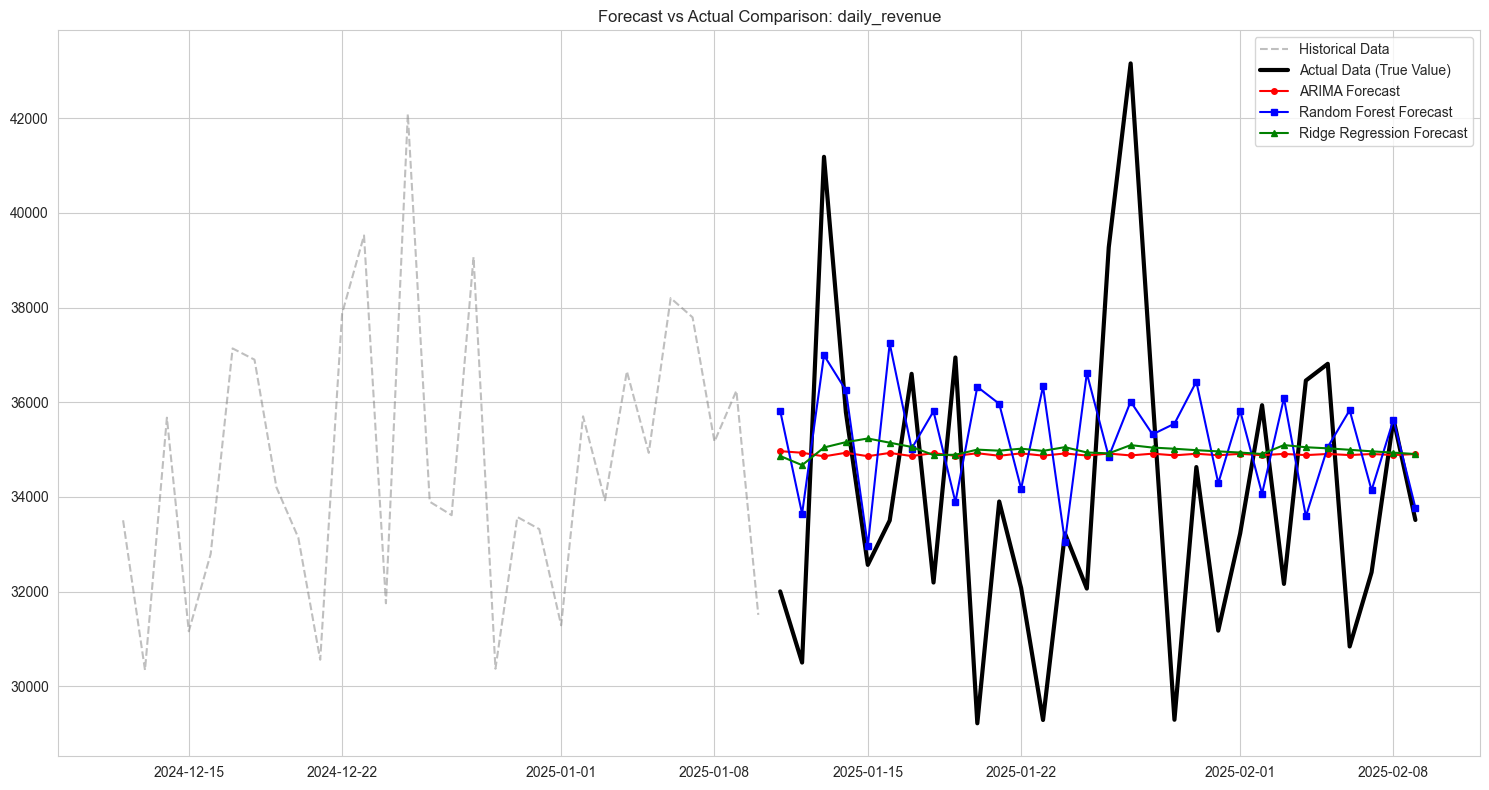

C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RITIK SINHA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


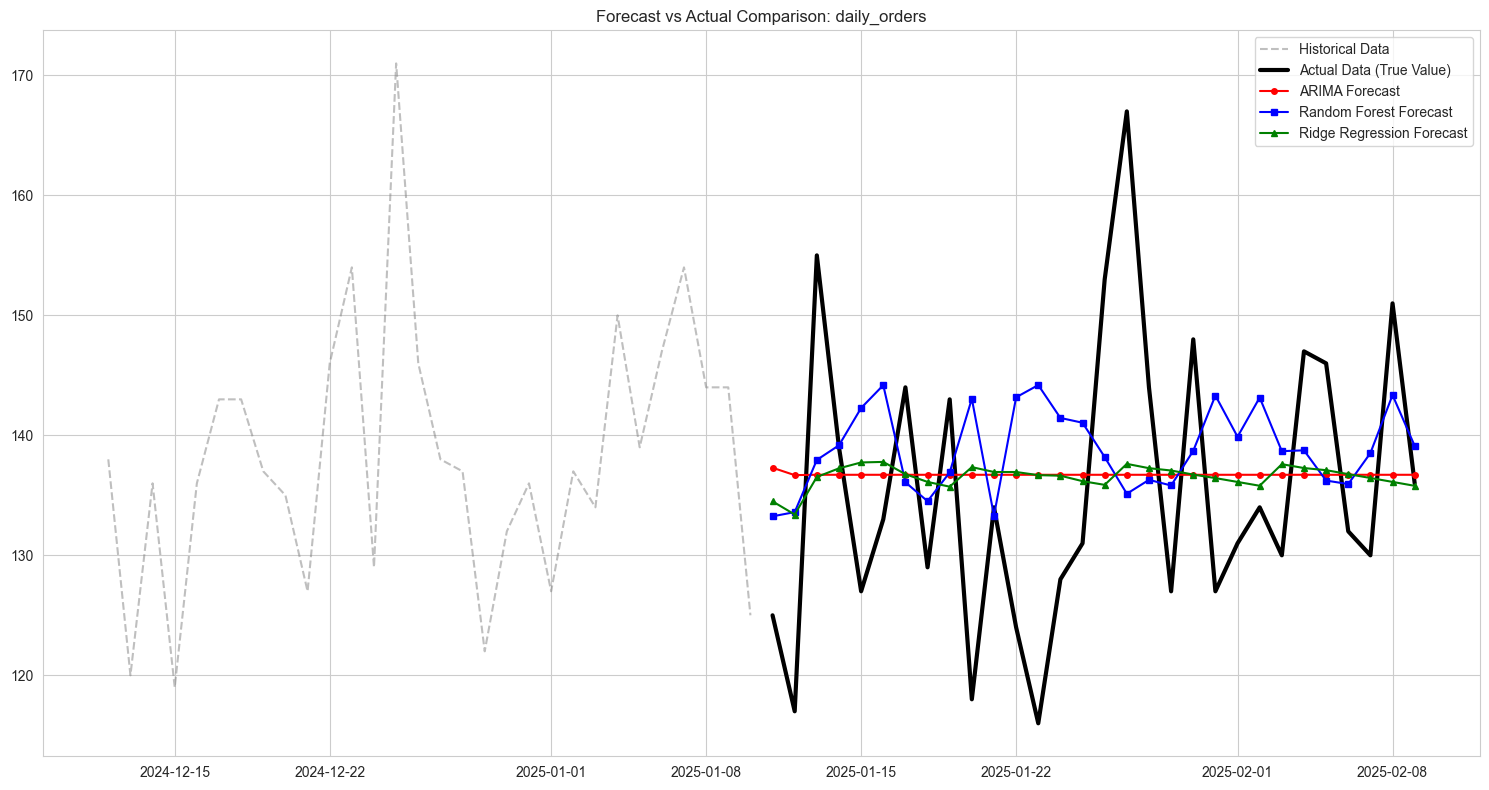

In [3]:
def plot_comparison_overlay(target_name):
    actual = df[target_name].iloc[-30:]
    history = df[target_name].iloc[-60:-30]
    
    preds_arima = get_arima_forecast(target_name)
    preds_rf = get_ml_forecast(target_name, 'RandomForest')
    preds_ridge = get_ml_forecast(target_name, 'Ridge')
    
    plt.figure(figsize=(15, 8))
    plt.plot(history, label='Historical Data', color='gray', alpha=0.5, linestyle='--')
    plt.plot(actual, label='Actual Data (True Value)', color='black', linewidth=3)
    
    plt.plot(preds_arima, label='ARIMA Forecast', color='red', marker='o', markersize=4)
    plt.plot(preds_rf, label='Random Forest Forecast', color='blue', marker='s', markersize=4)
    plt.plot(preds_ridge, label='Ridge Regression Forecast', color='green', marker='^', markersize=4)
    
    plt.title(f'Forecast vs Actual Comparison: {target_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04f_forecast_overlay_{target_name}.png')
    plt.show()

plot_comparison_overlay('daily_revenue')
plot_comparison_overlay('daily_orders')